# SPRINT 10: ANALÍTICA DE DADES EN PYTHON

## NIVELL 1

### EXERCICI 1

- Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.
- Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.
- Mostra les primeres 10 files.
- Addicionalment, fes un print on comprovi que el DNI només té valors únics.


In [1]:
import pandas as pd
df=pd.read_excel(r'sprint10.xlsx',header=3,index_col=0)

df.sort_values(['País d\'origen', 'Ciutat'], inplace=True)
print(df.head(10))
# Para saber si hay duplicados le pedimos que mire la columna DNI del DataFrame ordenado 
# y que mire si hay algún duplicado si lo hay nos responderá True si no False.

if df['DNI'].duplicated().any():
    print('Hay duplicados')
else:
    print('No hay duplicados')

       Nom              Cognoms        DNI País d'origen   Ciutat  \
21     Mia    Schneider Fischer  28973553Z      Alemanya   Berlín   
154  Laura    Schneider Fischer  37399141L      Alemanya   Berlín   
224    Lea  Schneider Schneider  37368317L      Alemanya   Berlín   
278    Mia              Fischer  21390098Z      Alemanya   Berlín   
602  Jonas            Schneider  44060014R      Alemanya   Berlín   
871    Lea              Fischer  14773153R      Alemanya   Berlín   
281    Lea               Müller  23266650S      Alemanya  Hamburg   
435   Anna               Müller  83274277X      Alemanya  Hamburg   
444  Laura       Schmidt Müller  60161784X      Alemanya  Hamburg   
487  Lukas       Müller Fischer  60982309S      Alemanya  Hamburg   

     Dia de Naixement  Mes de Naixement  Any de Naixement Gènere  \
21                 22                10              1976      A   
154                 2                 2              1958      D   
224                23               

### Exercici 2

- Crea una columna que sigui el nom complet.
- Crea una columna si la persona és nascuda a Espanya o no.
- Posa el DNI com a índex del DataFrame (noms de files).
- Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.
- Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).
Mostra tots els canvis que has realitzat en una sola taula.


In [2]:

# Unir dos columnas string
df['Nom_complet']=df['Nom'] +' '+ df['Cognoms']
df.insert(df.columns.get_loc('Cognoms') + 1,'Nom_complet',df.pop('Nom_complet'))

# utilizo el Loc[] para crear nueva columna en función de una condición de una columna existente
df.loc[df['País d\'origen']=='Espanya','Nacionalitat_espanyola']='Si'
df.loc[df['País d\'origen']!='Espanya','Nacionalitat_espanyola']='No'
# POngo la columna en la loc que creo que va mejor para seguir la información de los datos. Me dá toc que vaya al final
df.insert(df.columns.get_loc('País d\'origen')+1,'Nacionalitat_espanyola',df.pop('Nacionalitat_espanyola'))

# Pasar una columna a indice
df.set_index('DNI',inplace=True)
# o	Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.

df.rename(columns={'Dia de Naixement':'Dia','Mes de Naixement':'Mes','Any de Naixement':'Any'},inplace=True)
# Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).

df['Gènere'].replace(['A','H','D','NC'],['Altres','Home','Dona','Nan'],inplace=True)
# poner sólo las columnas que se han cambiado

display(df[['Nom_complet','Nacionalitat_espanyola',	'Dia','Mes','Any','Gènere']])

,Nom_complet,Nacionalitat_espanyola,Dia,Mes,Any,Gènere
DNI,,,,,,
28973553Z,Mia Schneider Fischer,No,22,10,1976,Altres
37399141L,Laura Schneider Fischer,No,2,2,1958,Dona
37368317L,Lea Schneider Schneider,No,23,10,2005,Dona
21390098Z,Mia Fischer,No,11,8,1950,Dona
44060014R,Jonas Schneider,No,22,11,1985,Home
...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,No,28,3,1958,Dona
57441590Y,George Brown Jones,No,27,12,1979,Home
58204038A,Olivia Brown Brown,No,28,8,1952,Altres


### Exercici 3

- Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".


In [3]:

#Otra manera de crearla es con método apply(), que es lo que nos piden:

# Creo la función que se aplicará en apply, para sustituir los valores por si o no en función de la columna:
def cambio_valor_fills(fila):
    if fila['Fills']==1.0:
        return 'Si'
    elif fila['No Fills']==1.0:
        return 'No'
# Aplico la función a la columna Fills que es la que va a permanecer
df['Fills']=df.apply(cambio_valor_fills,axis=1)
# elimino la columna No Fills que ya no se necesita
df.drop(columns='No Fills',inplace=True)

df

,Nom,Cognoms,Nom_complet,País d'origen,Nacionalitat_espanyola,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,No,Berlín,22,10,1976,Altres,951 €,No,Grup A
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,No,Berlín,2,2,1958,Dona,1.769 €,Si,Grup B
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,No,Berlín,23,10,2005,Dona,2.013 €,No,Grup B
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,No,Berlín,11,8,1950,Dona,1.557 €,Si,Grup B
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,No,Berlín,22,11,1985,Home,2.754 €,Si,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Emily Taylor Jones,Regne Unit,No,Manchester,28,3,1958,Dona,2.033 €,No,Grup B
57441590Y,George,Brown Jones,George Brown Jones,Regne Unit,No,Manchester,27,12,1979,Home,1.130 €,Si,Grup A
58204038A,Olivia,Brown Brown,Olivia Brown Brown,Regne Unit,No,Manchester,28,8,1952,Altres,1.023 €,No,Grup A


### Exercici 4

- Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
- Ordena la taula en funció del sou mig.


In [4]:
# Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
# 
# Primero modifico la columna Salari mensual para que deje de considerarse un string.

df['Salari mensual']=df['Salari mensual'].str.replace(r'[€.]','',regex=True).astype('float').round(2)


# He optado por esta opción de representar el groupBY.Esta es para cuando has de traspasar el código para que quede más claro y para personalizxar columnas
df.groupby('Gènere').agg(Salario_medio=('Salari mensual', 'mean'),Salario_max=('Salari mensual','max'),Salario_min=('Salari mensual','min'),Salario_mediana=('Salari mensual','median')).round(2).sort_values('Salario_medio')



,Salario_medio,Salario_max,Salario_min,Salario_mediana
Gènere,,,,
Dona,1469.44,3021.0,665.0,1361.5
Nan,1568.87,2969.0,758.0,1443.0
Altres,1626.59,3175.0,703.0,1545.0
Home,1643.25,3356.0,737.0,1531.0


### Exercici 5

- Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
- Afegeix-hi les mitjanes als marges de la taula.

(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats


In [5]:
import seaborn as sns
df_resum=pd.crosstab(df['Gènere'],df['País d\'origen'],values=df['Salari mensual'],aggfunc='mean',margins=True,margins_name='Total').round(2)
df_resum.fillna(0,inplace=True)
df_resum

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Total
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,0.00,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Nan,1931.50,1135.67,1252.00,1597.14,1573.00,1316.00,1365.50,1583.00,1553.50,1758.00,1568.87
Total,1858.35,1431.68,1489.13,1582.16,1465.36,1421.17,1441.69,1559.08,1527.23,1448.33,1561.46


In [ ]:
#  Aplica format condicional a la taula per veure en un color més intens els valors més elevats
# al final he cambiado el color y además en negrita, si ponía solo negrita no se apreciaba. He entendido que como piden 
# que resaltemos los valores mas altos he aplicado el cambio de estilo a los valores máximo con un color de caracter diferente

df_resum_styler =df_resum.style.apply(lambda x:['color: green; font-weight: bold;' if v == x.max() else'' for v in x])\
    .format("{:.2f} €")
df_resum_styler


País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Total
Gènere,,,,,,,,,,,
Altres,951.00 €,1141.00 €,1030.00 €,1706.18 €,0.00 €,1423.00 €,1365.00 €,1372.00 €,1765.00 €,1921.00 €,1626.59 €
Dona,1804.31 €,1291.80 €,1497.75 €,1460.16 €,1566.47 €,1247.18 €,1405.21 €,1517.80 €,1488.55 €,1489.46 €,1469.44 €
Home,2067.43 €,1583.29 €,1554.67 €,1682.11 €,1389.25 €,1672.88 €,1531.00 €,1625.00 €,1497.00 €,1162.56 €,1643.25 €
Nan,1931.50 €,1135.67 €,1252.00 €,1597.14 €,1573.00 €,1316.00 €,1365.50 €,1583.00 €,1553.50 €,1758.00 €,1568.87 €
Total,1858.35 €,1431.68 €,1489.13 €,1582.16 €,1465.36 €,1421.17 €,1441.69 €,1559.08 €,1527.23 €,1448.33 €,1561.46 €


### Exercici 6

- Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. 
- Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
- Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.


In [ ]:
# - Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. 

from datetime import datetime, date, time, timedelta
# Creo una fecha a partir de dia año y mes 
df['Data_naixement']=df.apply(lambda x: datetime(x['Any'],x['Mes'],x['Dia']),axis=1)
# Organizo la columna según como creo que tiene coherencia el mostrar los datos del dataframe. 
# Por eso la pongo despues de año de nacimiento y no la dejo al final
df.insert(df.columns.get_loc('Any') + 1,'Data_naixement',df.pop('Data_naixement'))

df

,Nom,Cognoms,Nom_complet,País d'origen,Nacionalitat_espanyola,Ciutat,Dia,Mes,Any,Data_naixement,Gènere,Salari mensual,Fills,Grup Professional
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,No,Berlín,22,10,1976,1976-10-22,Altres,951.0,No,Grup A
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,No,Berlín,2,2,1958,1958-02-02,Dona,1769.0,Si,Grup B
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,No,Berlín,23,10,2005,2005-10-23,Dona,2013.0,No,Grup B
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,No,Berlín,11,8,1950,1950-08-11,Dona,1557.0,Si,Grup B
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,No,Berlín,22,11,1985,1985-11-22,Home,2754.0,Si,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Emily Taylor Jones,Regne Unit,No,Manchester,28,3,1958,1958-03-28,Dona,2033.0,No,Grup B
57441590Y,George,Brown Jones,George Brown Jones,Regne Unit,No,Manchester,27,12,1979,1979-12-27,Home,1130.0,Si,Grup A
58204038A,Olivia,Brown Brown,Olivia Brown Brown,Regne Unit,No,Manchester,28,8,1952,1952-08-28,Altres,1023.0,No,Grup A


In [ ]:
# - Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
# Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.
from datetime import date,datetime,timedelta
def calculo_edad(fecha):

    fecha_actual=date.today()
    edad=fecha_actual.year-fecha.year
    # como la edat no sólo va en función del año de nacimiento si no que 
    # también del día y del mes se crea el if para restar un año si todavía no ha llegado el día y mes de tu cumpleaños
    if fecha_actual.month < fecha.month: 
        edad-=1
    elif fecha_actual.month == fecha.month and fecha_actual.day < fecha.day:
        edad-=1
    return edad
# Llamada a la función para crear la nueva columna
df['Edat']=df['Data_naixement'].apply(calculo_edad)
# POngo la columna en la posición coherente dentro del dataframe
df.insert(df.columns.get_loc('Data_naixement')+1,'Edat',df.pop('Edat'))
df


,Nom,Cognoms,Nom_complet,País d'origen,Nacionalitat_espanyola,Ciutat,Dia,Mes,Any,Data_naixement,Edat,Gènere,Salari mensual,Fills,Grup Professional
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,No,Berlín,22,10,1976,1976-10-22,49,Altres,951.0,No,Grup A
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,No,Berlín,2,2,1958,1958-02-02,67,Dona,1769.0,Si,Grup B
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,No,Berlín,23,10,2005,2005-10-23,20,Dona,2013.0,No,Grup B
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,No,Berlín,11,8,1950,1950-08-11,75,Dona,1557.0,Si,Grup B
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,No,Berlín,22,11,1985,1985-11-22,40,Home,2754.0,Si,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Emily Taylor Jones,Regne Unit,No,Manchester,28,3,1958,1958-03-28,67,Dona,2033.0,No,Grup B
57441590Y,George,Brown Jones,George Brown Jones,Regne Unit,No,Manchester,27,12,1979,1979-12-27,45,Home,1130.0,Si,Grup A
58204038A,Olivia,Brown Brown,Olivia Brown Brown,Regne Unit,No,Manchester,28,8,1952,1952-08-28,73,Altres,1023.0,No,Grup A


## Nivell 2

### Exercici 1

- Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.
- Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":["5%","3,5%","2%","8%"]})


In [ ]:
# Primero ejecutamos
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":["5%","3,5%","2%","8%"]})
# quitamos símbolo % y reemplazamos , por .
df_increment.replace(['%',','],['','.'],regex=True,inplace=True)
# hacemos que el indice sea la columna grup
df_increment.set_index(['Grup'],inplace=True)
df_increment


,Increment
Grup,
Grup A,5
Grup B,3.5
Grup C,2
Grup D,8


In [ ]:
# A partir de aquí, creamos la nueva columna mapeando la columna 'Grup Professional' con map() del df_increment convertido a diccionario
df['Increment(%)']=df['Grup Professional'].map(df_increment['Increment'].astype('float64').to_dict())
#  Pongo la columna donde tiene sentido
df.insert(df.columns.get_loc('Salari mensual')+1,'Increment(%)',df.pop('Increment(%)'))
df


,Nom,Cognoms,Nom_complet,País d'origen,Nacionalitat_espanyola,Ciutat,Dia,Mes,Any,Data_naixement,Edat,Gènere,Salari mensual,Increment(%),Fills,Grup Professional
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,No,Berlín,22,10,1976,1976-10-22,49,Altres,951.0,5.0,No,Grup A
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,No,Berlín,2,2,1958,1958-02-02,67,Dona,1769.0,3.5,Si,Grup B
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,No,Berlín,23,10,2005,2005-10-23,20,Dona,2013.0,3.5,No,Grup B
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,No,Berlín,11,8,1950,1950-08-11,75,Dona,1557.0,3.5,Si,Grup B
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,No,Berlín,22,11,1985,1985-11-22,40,Home,2754.0,8.0,Si,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Emily Taylor Jones,Regne Unit,No,Manchester,28,3,1958,1958-03-28,67,Dona,2033.0,3.5,No,Grup B
57441590Y,George,Brown Jones,George Brown Jones,Regne Unit,No,Manchester,27,12,1979,1979-12-27,45,Home,1130.0,5.0,Si,Grup A
58204038A,Olivia,Brown Brown,Olivia Brown Brown,Regne Unit,No,Manchester,28,8,1952,1952-08-28,73,Altres,1023.0,5.0,No,Grup A


In [ ]:
# - Actualitza la columna salari en funció dels percentatges que s'adjunten. 
# No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.
# El enunciado no me queda claro de si se ha de crear una columna nueva o si se han de sustituir los valores de la existente. 
# Con lo que he decidido crear una nueva.


df['Salari_actualitzat']=df.apply(lambda x: round(x['Salari mensual']+(x['Salari mensual']*(x['Increment(%)'])/100),2),axis=1)

df.insert(df.columns.get_loc('Increment(%)')+1,'Salari_actualitzat',df.pop('Salari_actualitzat'))
df

,Nom,Cognoms,Nom_complet,País d'origen,Nacionalitat_espanyola,Ciutat,Dia,Mes,Any,Data_naixement,Edat,Gènere,Salari mensual,Increment(%),Salari_actualitzat,Fills,Grup Professional
DNI,,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,No,Berlín,22,10,1976,1976-10-22,49,Altres,951.0,5.0,998.55,No,Grup A
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,No,Berlín,2,2,1958,1958-02-02,67,Dona,1769.0,3.5,1830.91,Si,Grup B
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,No,Berlín,23,10,2005,2005-10-23,20,Dona,2013.0,3.5,2083.45,No,Grup B
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,No,Berlín,11,8,1950,1950-08-11,75,Dona,1557.0,3.5,1611.49,Si,Grup B
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,No,Berlín,22,11,1985,1985-11-22,40,Home,2754.0,8.0,2974.32,Si,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Emily Taylor Jones,Regne Unit,No,Manchester,28,3,1958,1958-03-28,67,Dona,2033.0,3.5,2104.16,No,Grup B
57441590Y,George,Brown Jones,George Brown Jones,Regne Unit,No,Manchester,27,12,1979,1979-12-27,45,Home,1130.0,5.0,1186.50,Si,Grup A
58204038A,Olivia,Brown Brown,Olivia Brown Brown,Regne Unit,No,Manchester,28,8,1952,1952-08-28,73,Altres,1023.0,5.0,1074.15,No,Grup A


### Exercici 2

- Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.
  Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...
- Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.


In [ ]:
# - Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.
#   Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...
# Va filtrando los valores de los índices cuyo valor en la columna Grup professional es la categoría y se seleccionan todas las columnas, 
# se exporta a un archivo por cada categoría diferente que la obtienes del listado de valores únicos de la columna grup categorías
for categoria in df['Grup Professional'].unique():
    df.loc[(df['Grup Professional']==categoria), : ].to_excel(f'dades_{categoria}.xlsx')   

In [ ]:
# - Exporta un 5è DataFrame en format .xlsx o .csv que contingui:
#  quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.
# Se crea el df con los datos solicitados:

df.groupby('Grup Professional').agg(numero_trabajadores=('Nom','count'),sou_mig=('Salari mensual','mean'),edat_mitjana=('Edat','mean')).round(2).to_excel('resum_grup_professional.xlsx')


## Nivell 3

### Exercici 1

Crea una funció que prengui un dataframe com a paràmetre d'entrada.
La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. 

Per exemple:

- un histograma/boxplot si la variable és numèrica
- unes barres dels valors més freqüents si és categòrica
- unes barres dels anys més freqüents si la dada està en format de data.

La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.
Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
        
def grafic_dataframe(dataframe):
    # Validar que es un objeto Dataframe lo que se envía
    if isinstance(dataframe,pd.DataFrame):
        if dataframe.empty:
            print('El dataframe que has introducido está vacío')
        else:
#  primero defino dataframes con columnas numéricas, categóricas y con formato date:
            # creo un dataframe con las columnas numéricas:
            df_col_numericas=dataframe.select_dtypes(include='number')
            # creo un dataframe con las columnas que no son ni números ni date time:
            df_col_categoricas=dataframe.select_dtypes(exclude=['number','datetime'])
            # creo una lista del nombre de las columnas que pandas permite transformarlas a date quitando las que son numéricas:
            lista_columnas_fechas=[]
            for col in dataframe.columns:
                try:
                    pd.to_datetime(dataframe[col])
                    if not col in df_col_numericas.columns:
                        lista_columnas_fechas.append(col)
                except:
                    pass

            #  Para graficar las columnas numéricas:
            if not df_col_numericas.empty:          
                for columna in df_col_numericas.columns:
                    df_col_numericas[columna].plot.box()
                    plt.show()
                    df_col_numericas[columna].plot.hist()
                    plt.show()
            else:
                print('No hay columnas númericas')
            # Para graficar las columnas categóricas que no puedan ser date
            
            if not df_col_categoricas.empty:
                for col in df_col_categoricas.columns:
                    if not col in lista_columnas_fechas:
                        conteo=df_col_categoricas[col].value_counts().sort_index()
                        conteo.plot.bar()
                        plt.show()
            else:
                print('No hay columnas categóricas')
            # Para graficar las columnas date:


            #  Una vez tengo la lista de columna que se pueden convertir a fecha
            if lista_columnas_fechas:
                for item in lista_columnas_fechas:
                    años=pd.to_datetime(dataframe[item]).dt.year
                    conteo_años=años.value_counts().sort_index()
                    conteo_años.plot.bar()
                    plt.show()
          
            else:
                print('No hay columnas tipo Date')

    else:
        print('El objeto que has introducido no es un dataframe')







C:\Users\vpere\AppData\Local\Temp\ipykernel_24812\445795641.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(dataframe[col])
C:\Users\vpere\AppData\Local\Temp\ipykernel_24812\445795641.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(dataframe[col])
C:\Users\vpere\AppData\Local\Temp\ipykernel_24812\445795641.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(dataframe[col])
C:\Users\vpere\AppData\Local\Temp\ipykernel_24812\445795641.py:19: UserWarning: Could not infer format, so each element will be parsed individually,

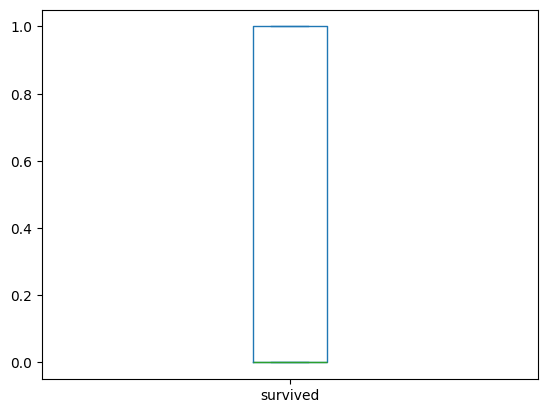

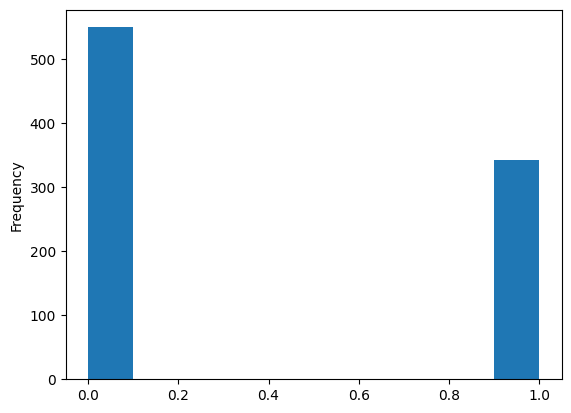

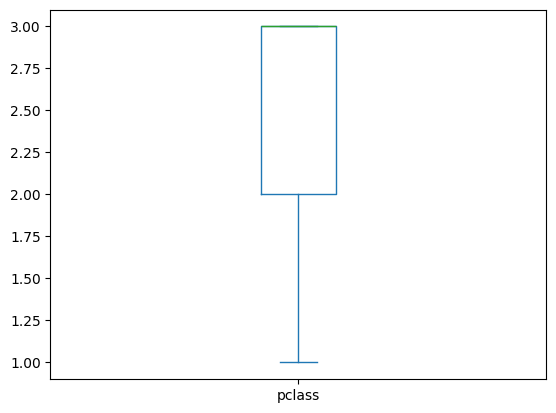

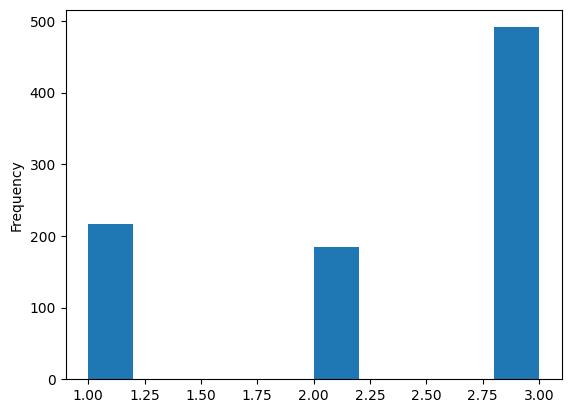

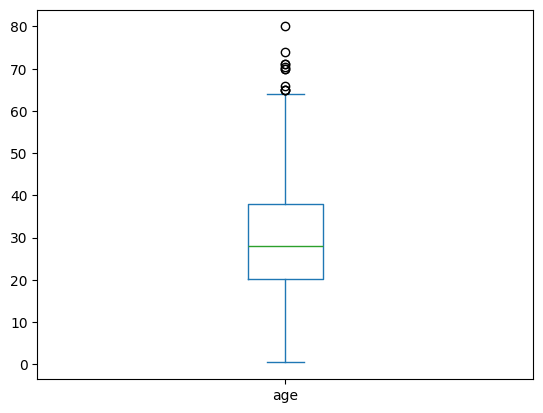

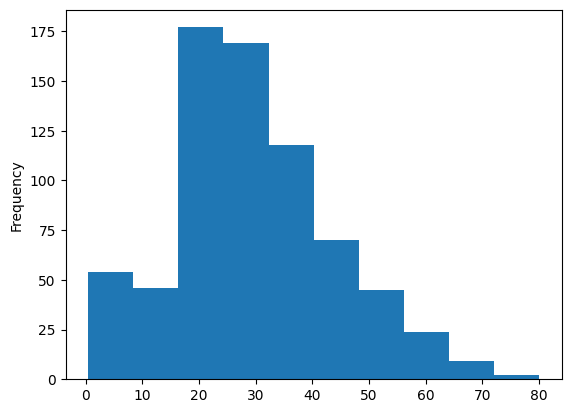

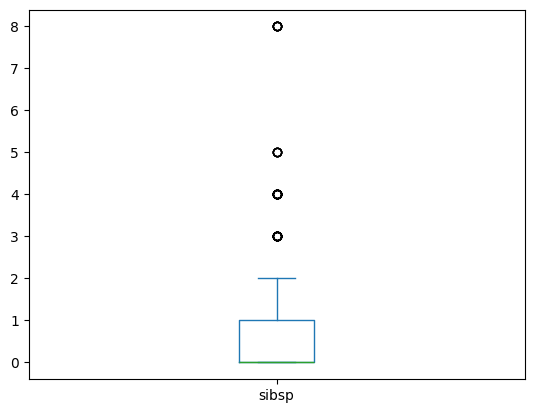

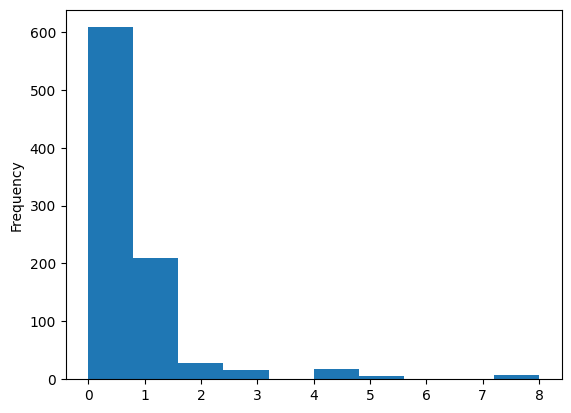

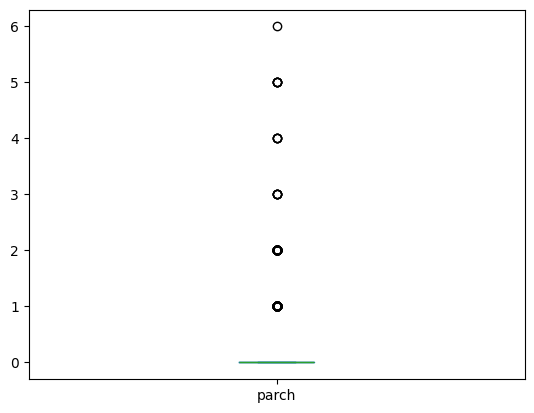

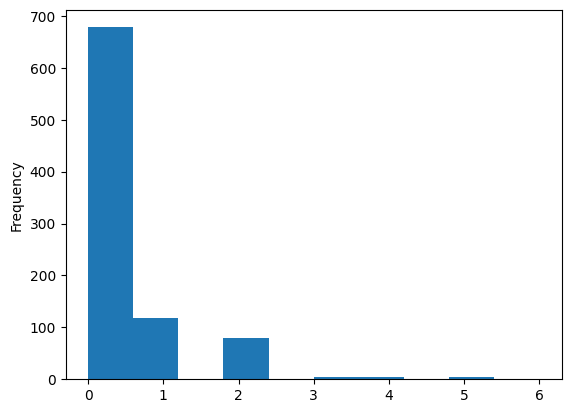

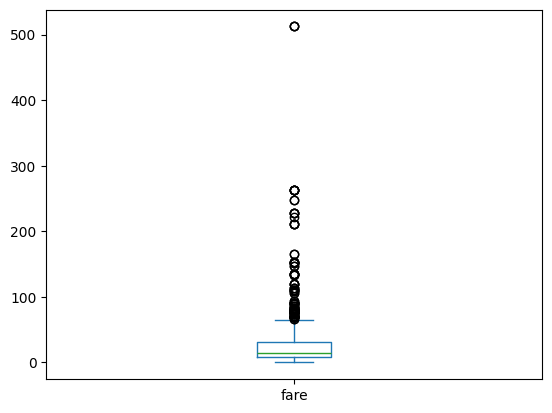

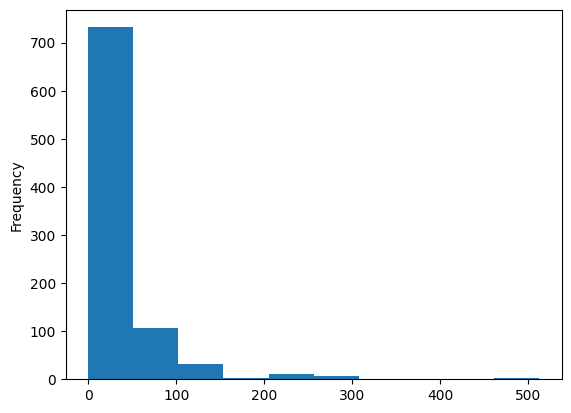

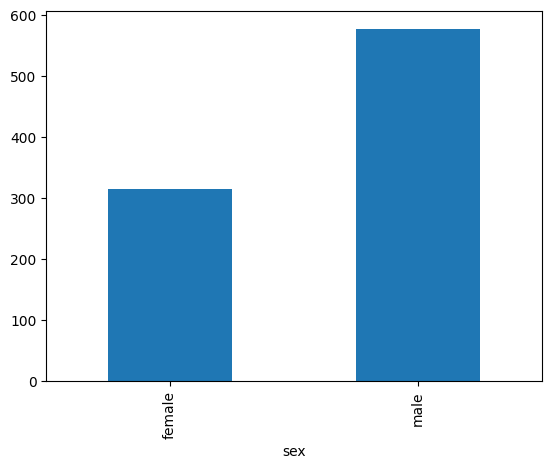

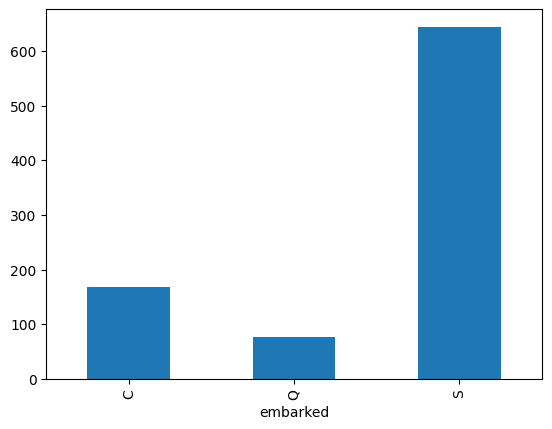

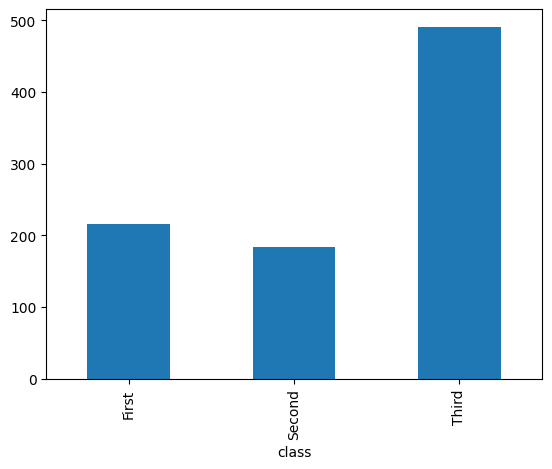

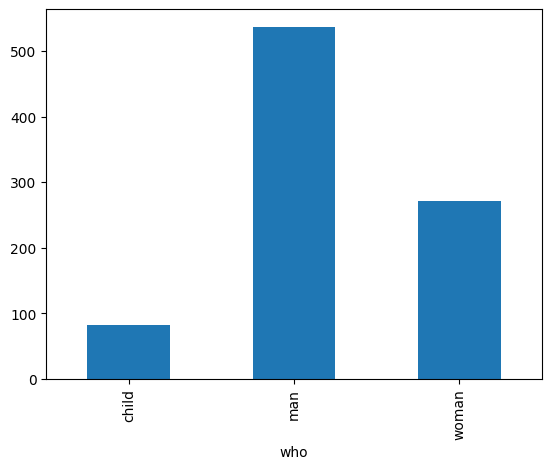

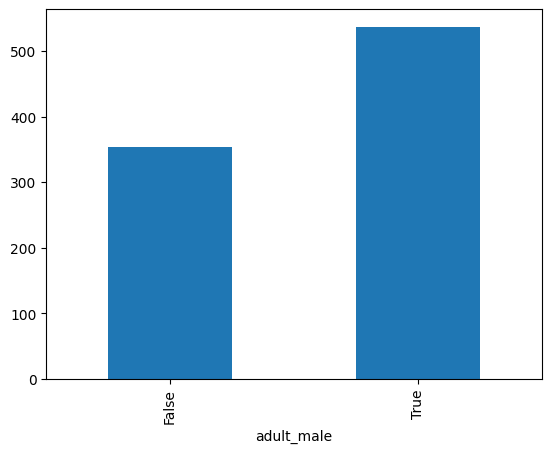

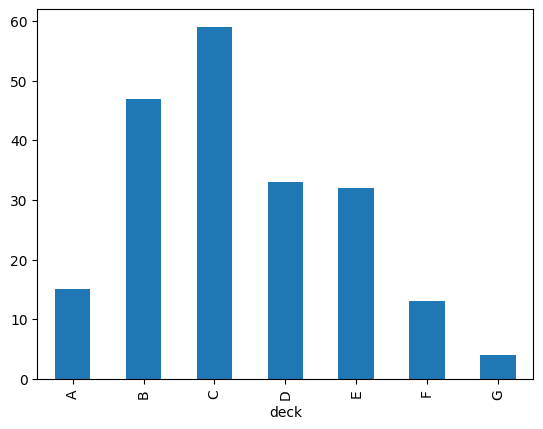

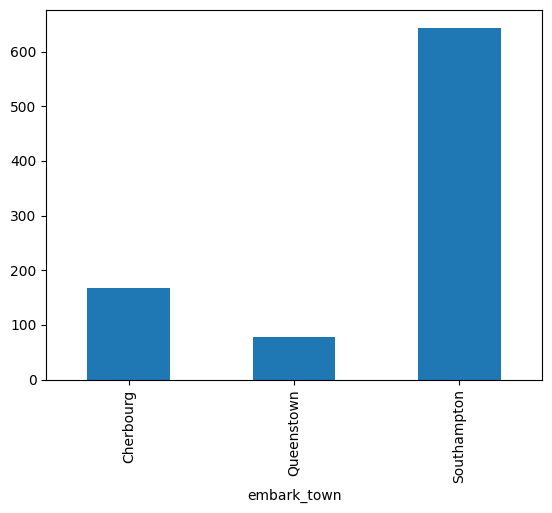

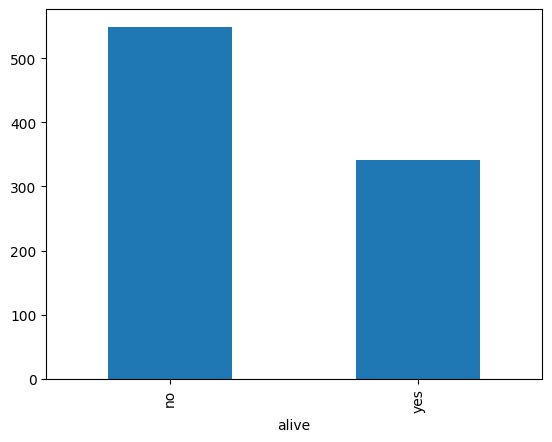

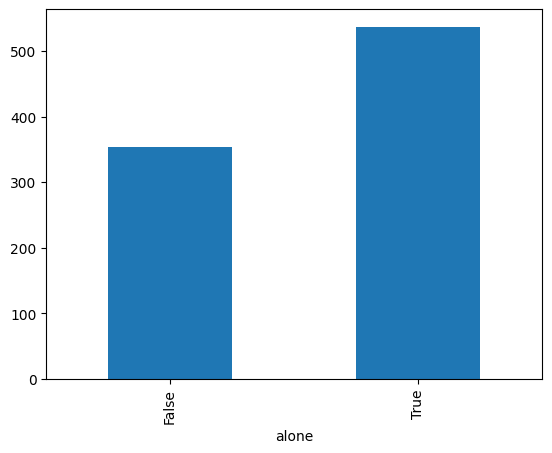

No hay columnas tipo Date


In [ ]:
import seaborn as sns
df2=sns.load_dataset('titanic')

df_entrado=globals().get(input('Introduce el nombre del dataframe.'))

grafic_dataframe(df_entrado)



### Exercici 2

Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara
Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.
(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat


In [ ]:
def recorrido_ciudades_principales(matriz,ciudad_de_partida):
    # pensar en poner try para asegurar si está en el índice y si no que retorne mensaje: PARA HACER MAS ADELANTE
    # PASARLO A DICCIONARIO UNA VEZ FUNCIONE
    recorrido=[ciudad_de_partida]
    km_recorridos=0
    ciudad_de_partida=ciudad_de_partida
    ciudades_pendientes_visitar=list(set(matriz.columns) - set(recorrido))
    x=1
    
    if ciudad_de_partida in matriz.index:        
            
        while x < len(matriz.columns): 
            # Calcula el nombre de la ciudad mas cercana: 
            ciudad_mas_cercana = matriz.loc[ciudad_de_partida].idxmin()                                              
                                    
            if not ciudad_mas_cercana in recorrido:
                recorrido.append(ciudad_mas_cercana)
                km_recorridos=matriz.loc[ciudad_de_partida,ciudad_mas_cercana]+km_recorridos
                ciudad_de_partida =ciudad_mas_cercana
                ciudades_pendientes_visitar=list(set(matriz.columns) - set(recorrido))
                
                x+=1
            else:
                distancias_ordenadas = matriz.loc[ciudad_de_partida, ciudades_pendientes_visitar].sort_values()
                ciudad_mas_cercana = distancias_ordenadas.index[0]
                recorrido.append(ciudad_mas_cercana)
                km_recorridos=matriz.loc[ciudad_de_partida,ciudad_mas_cercana]+km_recorridos
                ciudad_de_partida = ciudad_mas_cercana
                ciudades_pendientes_visitar = list(set(matriz.columns) - set(recorrido))
                                                    

                x+=1
    else:
        return(f'La ciudad {ciudad_de_partida} no está en el listado')
     
    return recorrido, km_recorridos


    # print('se acaba la función')

In [ ]:
import pandas as pd

df3=pd.read_excel(r'matriu_distancies.xlsx',header=0,index_col=0)

df3.drop(index=['Las Palmas de Gran Canaria','Palma'],columns=['Las Palmas de Gran Canaria','Palma'],inplace=True)

# Creo variable ciudad con input para hospitalet de llobregat, con title dá problemas con lo que lo he solucionado con que lo sutituya
ciudad_de_salida=input('¿desde dónde sales de viaje?').strip().title()
for palabra in [" De "]:
    ciudad_de_salida = ciudad_de_salida.replace(palabra, palabra.lower())

try:
    orden_visitas,distancia_total_recorrida=recorrido_ciudades_principales(df3,ciudad_de_salida)

    print(f'El recorrido más corto que debes seguir para visitar todas las ciudades saliendo de {ciudad_de_salida} son {distancia_total_recorrida}.\n Para ello debes seguir el siguiente itinerario:')
    print('->'.join(orden_visitas))


except:
    print(recorrido_ciudades_principales(df3,ciudad_de_salida))




El recorrido más corto que debes seguir para visitar todas las ciudades saliendo de Zaragoza son 3415.0.
 Para ello debes seguir el siguiente itinerario:
Zaragoza->Valencia->Alicante->Murcia->Córdoba->Sevilla->Málaga->Valladolid->Gijón->Bilbao->Hospitalet de Llobregat->Barcelona->Vigo


In [ ]:
# (EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat:

diccionario_recorridos={}

for ciudad in df3.index:
    orden_visitas,distancia_total_recorrida=recorrido_ciudades_principales(df3,ciudad)
    diccionario_recorridos.setdefault(ciudad,float(distancia_total_recorrida))


recorridos_ordenado=sorted(diccionario_recorridos.items(),key=lambda item: item[1])
ciudad, km = recorridos_ordenado[0]


print(f'La ciudad desde la que podemos hacer el recorrido mas corto es {ciudad}, con un total de {km} km.')



La ciudad desde la que podemos hacer el recorrido mas corto es Barcelona, con un total de 2778.0 km.
